## LOAD PACKAGE

In [1]:
#| export

# import kagglehub
# !pip install peft

import os
import io
import re
import random
import base64
from io import BytesIO

import time
from datetime import timedelta

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from IPython.display import SVG

from PIL import Image
import PIL


import cv2


from diffusers import StableDiffusionPipeline
from transformers import AutoProcessor, AutoModel
import metric


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Q1: Is there a red circle?
Predicted Answer: yes
Correct Answer  : yes
Probabilities   : {'yes': 0.901214732510082, 'no': 0.09878526748991795}

Q2: What shape is present?
Predicted Answer: circle
Correct Answer  : circle
Probabilities   : {'square': 0.00039966567346408317, 'circle': 0.9992734001747942, 'triangle': 0.0001767018281842993, 'hexagon': 0.0001502323235575014}

decoded text =  100
Q1: Is there a red circle?
Predicted Answer: yes
Correct Answer  : yes
Probabilities   : {'yes': 0.901214732510082, 'no': 0.09878526748991795}

Q2: What shape is present?
Predicted Answer: circle
Correct Answer  : circle
Probabilities   : {'square': 0.00039966567346408317, 'circle': 0.9992734001747942, 'triangle': 0.0001767018281842993, 'hexagon': 0.0001502323235575014}

decoded text =  100
Does <image> portray "SVG illustration of a red circle" without any lettering? Answer yes or no.
Q1: Is there a red circle?
Predicted Answer: yes
Correct Answer  : yes
Probabilities   : {'yes': 0.901214732510082,

## Competition Metric Helpers

We also want to evaluate metrics of the original bitmap before converting to svg. Let’s implement it using [metric package](https://www.kaggle.com/code/jiazhuang/svg-image-fidelity).

In [2]:
import numpy as np
import statistics
import pandas as pd

def image_resize(image, size=(384, 384)):
    return image.convert('RGB').resize(size)

def bitmap_score_instance_impl(multiple_choice_qa, image, random_seed=42):
    rng = np.random.RandomState(random_seed)
    group_seed = rng.randint(0, np.iinfo(np.int32).max)
    image_processor = metric.ImageProcessor(image=image_resize(image), seed=group_seed).apply()
    image = image_processor.image.copy()
    questions = multiple_choice_qa['question']
    choices = multiple_choice_qa['choices']
    answers = multiple_choice_qa['answer']
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    vqa_score = metric.vqa_evaluator.score(questions, choices, answers, image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    instance_score = metric.harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
    return instance_score, vqa_score, ocr_score, aesthetic_score

def bitmap_score_instance(multiple_choice_qa, image, random_seed=42):
    is_single = not isinstance(image, list)
    if is_single:
        multiple_choice_qa = [multiple_choice_qa]
        image = [image]
    
    assert len(multiple_choice_qa) == len(image)

    results = []
    score_df = []
    for one_image, one_multiple_choice_qa in zip(image, multiple_choice_qa, strict=True):
        instance_score, vqa_score, ocr_score, aesthetic_score = bitmap_score_instance_impl(one_multiple_choice_qa, one_image, random_seed=42)
        results.append(instance_score)
        score_df.append([instance_score, vqa_score, ocr_score, aesthetic_score])

    fidelity = statistics.mean(results)
    score_df = pd.DataFrame(score_df, columns=['competition_score', 'vqa_score', 'ocr_score', 'aesthetic_score'])
    if is_single:
        return score_df.iloc[0].to_dict()
    else:
        return float(fidelity), score_df

## Refiner

In [3]:
from diffusers import DiffusionPipeline, DDIMScheduler
from diffusers import DPMSolverMultistepScheduler
import torch

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# load both base & refiner
sdxl_model_path = 'stable-diffusion-xl-base-1.0'
sdxl_turbo_path = 'sdxl-turbo'
sdxl_refiner_path = 'stable-diffusion-xl-pytorch-refiner-1-0-v1'
lora_path = 'lora'

# Load and attach DDIM scheduler to base pipeline
scheduler = DDIMScheduler.from_pretrained(
    sdxl_model_path,
    subfolder="scheduler"
)

base = DiffusionPipeline.from_pretrained(
    sdxl_model_path, torch_dtype=torch.float16, variant="fp16", scheduler=scheduler, use_safetensors=True
)
base.to("cuda:0")

# add lora ====================================================

# # Load LoRA weights (local path or Hugging Face repo ID)
base.load_lora_weights(lora_path, weight_name='Vector_illustration_XL.safetensors')
# # To activate LoRA: specify `scale` (0.0 to 1.0, default 1.0)
base.fuse_lora(lora_scale=0.8)


base.unet = torch.compile(base.unet,  backend="eager", fullgraph=True)
refiner = DiffusionPipeline.from_pretrained(
    sdxl_refiner_path,
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    scheduler=scheduler,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.to("cuda:0")
refiner.unet = torch.compile(refiner.unet, backend="eager", fullgraph=True)

Using device: cuda:0


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

## base+refiner

In [4]:
#| export
def generate_bitmap(prompt, negative_prompt="", num_inference_steps=28, base_steps = 20, guidance_scale=20):
        
    n_steps = num_inference_steps
    high_noise_frac = base_steps/n_steps + 0.005
    
    # run both experts
    image = base(
        prompt=prompt,
        negative_prompt = negative_prompt,
        width=768,
        height=768,
        num_inference_steps=n_steps,
        denoising_end=high_noise_frac,
        output_type="latent",
    ).images
    image = refiner(
        prompt=prompt,
        negative_prompt = negative_prompt,
        width=768,
        height=768,
        num_inference_steps=n_steps,
        denoising_start=high_noise_frac,
        image=image,
    ).images[0]
    
    return image

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

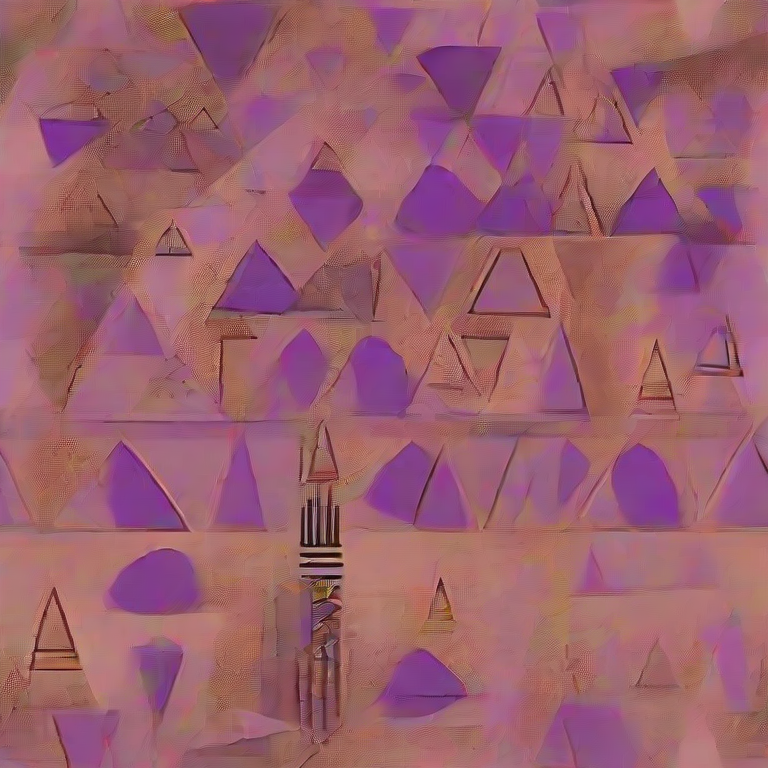

In [5]:
# triiger the compilation first
description = 'purple pyramids spiraling around a bronze cone'
img = generate_bitmap(prompt = description, negative_prompt = '', num_inference_steps = 4, guidance_scale = 7.5)
display(img)

## Load Data

In [6]:
import pandas as pd
import json

In [7]:
train_df = pd.read_csv('train.csv')
train_question_df = pd.read_parquet('questions.parquet')

In [8]:
train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))
train_question_df = train_question_df.reset_index(name='qa')

train_question_df['question'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['question'], ensure_ascii=False))

train_question_df['choices'] = train_question_df.qa.apply(
    lambda qa: json.dumps(
        [x.tolist() for x in qa['choices']], ensure_ascii=False
    )
)

train_question_df['answer'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['answer'], ensure_ascii=False))

train_df = pd.merge(train_df, train_question_df, how='left', on='id')

train_df['multiple_choice_qa'] = train_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

train_df.head()

C:\Users\YongsanHuang\AppData\Local\Temp\ipykernel_29832\3218796089.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))


,id,description,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


# FUNCTION img -> svg

In [9]:
import re
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "output.png"
output_path = "output.svg"

In [10]:
import re
def convert_paths_to_polygons(svg_code: str, size: int) -> str:
    # Find all path elements
    scale_factor = 384 / size

    path_pattern = re.compile(
        r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
    )
    paths = path_pattern.findall(svg_code)

    polygons = []

    for d_content, fill_color, translate in paths:
        tx, ty = map(float, translate.split(','))
        points = []
        tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
        for token in tokens:
            if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
                continue
            x_str, y_str = token.split(',')
            x = int(round(float(x_str) + tx))
            y = int(round(float(y_str) + ty))
            points.append(f"{x},{y}")

        if points:
            polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
            polygons.append(polygon)

    # Build the compact SVG
    new_svg = (
        f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
        + "".join(polygons)
        + '</g></svg>'
    )

    return new_svg


def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code


def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection_a1 = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white"/>'      # Bottom-left A
    injection_a2 = '\n<path d="M364 30 L370 20 L376 30 M367 25 L373 25" stroke="white"/>'         # Top-right A
    injection = injection_a1 + injection_a2
    injection_length = len(injection)

    # Binary search for best layer_difference
    low = 1
    high = 200
    best_svg_code = None
    best_layer_difference = 10

    while low <= high:
        layer_difference = (low + high) // 2

        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        
            hierarchical='stacked',  
            mode='polygon',          
            filter_speckle=1,         
            color_precision=8,      
            layer_difference=layer_difference, 
            corner_threshold=60,     
            length_threshold=50,     
            max_iterations=10,        
            splice_threshold=45,     
            path_precision=8         
        )

        # Step 3: Read and display the SVG
        try:
            with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
        except UnicodeDecodeError:
            # Bad SVG output (probably corrupted), try again
            high = layer_difference - 1
            continue  # go back to binary search

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
        
        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # use polygon instead of path
        svg_code = convert_paths_to_polygons(svg_code, size)
            
        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length:
            best_svg_code = svg_code
            best_layer_difference = layer_difference
            high = layer_difference - 1  # search for even more detail
        else:
            low = layer_difference + 1  # simplify more

    svg_code = fix_svg_size(best_svg_code, target_size=384) # doesnt change length

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")

    print(f'{best_layer_difference=}')
    return svg_code


# SD evaluator

In [11]:
# | export
def get_aes_and_ocr_score(svg_content):
    image_processor = metric.ImageProcessor(image=metric.svg_to_png(svg_content), seed=42).apply()
    image = image_processor.image.copy()
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    return aesthetic_score, ocr_score




## Implement the package Model class

In [17]:
#| export
import time
class Model:
    def __init__(self):
        self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
        self.prompt_prefix = "a stylized digital painting presenting a"
        self.prompt_suffix = " from distance. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece."
        self.negative_prompt = 'text, logo, mirror reflection, high-reflective, lines, deformed, ugly, wrong proportion, low res, bad anatomy, worst quality, low quality, framing, hatching, patterns, outlines'
        self.num_attempt = 3

    # def __init__(self):
    #     self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
    #     self.prompt_prefix = "Simple, classic image of"
    #     self.prompt_suffix = "with flat color blocks, beautiful, minimal details, solid colors only"
    #     self.negative_prompt = "text, signature, framing, hatching, background, textures, patterns, outlines"
    #     # self.num_inference_steps = 40
    #     # self.guidance_scale = 20
    #     self.num_attempt = 3

    def gen_bitmap(self, description):
        prompt = f'{self.prompt_prefix} {description}{self.prompt_suffix}'
        bitmap = generate_bitmap(prompt = prompt, negative_prompt = self.negative_prompt)
        return bitmap

    def predict_impl(self, prompt: str) -> str:
        best_score = 0.0
        best_svg = None
        best_img = None
        start_time = time.time()
        print(f'======  {prompt}  =======')
        for i in range(self.num_attempt):
            if time.time() - start_time > 50:
                print(f"Timeout reached at attempt {i}. Returning current best result.")
                break
            bitmap = self.gen_bitmap(prompt)
            svg = bitmap_to_svg_layered(bitmap, input_path, output_path)
            aesthetic_score, ocr_score = get_aes_and_ocr_score(svg)
            score = aesthetic_score * ocr_score
            print(f'{score=}')
            print('svg length:', len(svg))
            if score >= best_score:
                best_score = score
                best_svg = svg
                best_img = bitmap
        print('final score:', best_score)
        print('=======================================================================')
        
        if best_svg is None:
            best_svg = self.default_svg

        return best_svg, best_img

    def predict(self, prompt: str) -> str:
        svg, img = self.predict_impl(prompt)
        return svg


In [18]:
model = Model()

======  magenta trapezoids layered on a transluscent silver sheet  =======


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

best_layer_difference=38
decoded text =  A
score=0.5002
svg length: 9548


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

best_layer_difference=29
decoded text =  A
score=0.5382
svg length: 9618


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

best_layer_difference=36
decoded text =  A
score=0.412
svg length: 9819
final score: 0.5382


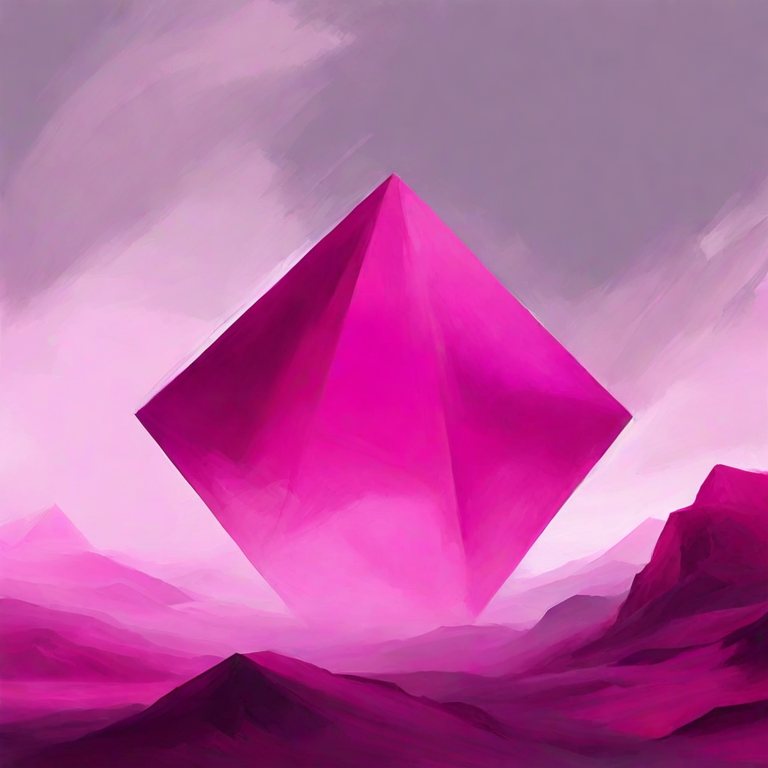

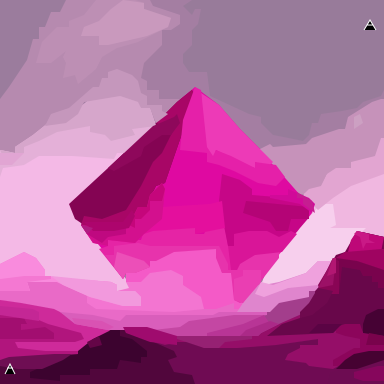

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#A47EA2"/><polygon points="65,29 73,35 80,43 100,63 100,65 104,67 105,71 91,88 83,99 80,101 78,100 77,91 74,91 72,86 72,83 58,84 52,87 50,87 50,89 45,91 42,91 41,93 31,81 23,70 25,66 35,57 52,41 59,34" fill="#DF09A1"/><polygon points="119,77 128,79 128,128 0,128 0,120 3,119 26,117 31,113 38,109 49,109 56,110 63,107 89,104 95,99 103,99 103,97 108,93 112,85 115,84" fill="#6F0B53"/><polygon points="64,0 128,0 128,30 127,32 121,34 119,36 114,37 107,38 106,41 104,41 103,45 101,47 91,45 87,41 87,39 83,38 70,32 69,24 63,24 61,21 61,18 64,15 64,10 66,8 67,3 65,3 64,5 61,2" fill="#987B9A"/><polygon points="40,31 46,33 47,36 50,36 52,42 43,51 35,58 28,65 24,68 26,73 38,88 42,93 47,93 50,90 57,89 61,92 62,95 68,99 68,103 58,104 32,103 29,101 29,98 19,94 9,94 10,97 0,97 0,50 5,51 5,49 11,45 16,41 23,39 30,33" fill="#F4B9E6"/><polygon points="0,0 50,0 51,2 60,5 60,8 57,10 54

In [19]:
%%time
r = train_df.iloc[9]
description = r.description
svg, img = model.predict_impl(description)
display(img)
display(SVG(svg))
print(svg)

In [20]:
metric.score_instance(r.multiple_choice_qa, svg, random_seed=42)

Q1: Is the color silver present in the image?
Predicted Answer: no
Correct Answer  : yes
Probabilities   : {'no': 0.9820168592019498, 'yes': 0.017983140798050235}

Q2: Which word describes the silver sheet's ability to let light through?
Predicted Answer: reflective
Correct Answer  : translucent
Probabilities   : {'opaque': 0.0009828938674909568, 'reflective': 0.9927970790604562, 'solid': 0.0004048647672993255, 'translucent': 0.005815162304753489}

Q3: Are the trapezoids layered on something?
Predicted Answer: no
Correct Answer  : yes
Probabilities   : {'no': 0.6739967325430205, 'yes': 0.3260032674569795}

Q4: What shape are the magenta objects?
Predicted Answer: trapezoids
Correct Answer  : trapezoids
Probabilities   : {'circles': 0.0014002532196586374, 'stars': 0.0012208634690235023, 'trapezoids': 0.9954576846397317, 'triangles': 0.0019211986715861177}

decoded text =  A


{'competition_score': 0.3623899446454414,
 'vqa_score': 0.3363148137998787,
 'ocr_score': 1.0,
 'aesthetic_score': 0.5253}

## Evaluate on train dataset (LB prediction!)

  0%|          | 0/15 [00:00<?, ?it/s]

======  a purple forest at dusk  =======


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

best_layer_difference=52
decoded text =  A
score=0.5688
svg length: 9866


...

best_layer_difference=60
decoded text =  A
A
score=0.4341
svg length: 9996
final score: 0.5414


  0%|          | 0/15 [00:00<?, ?it/s]

Q1: What is the main setting of the image?
Predicted Answer: forest
Correct Answer  : forest
Probabilities   : {'beach': 0.0004633758714449656, 'desert': 0.00030023466226759604, 'forest': 0.9989530232593349, 'mountain': 0.0002833662069525812}

Q2: Is there anything purple in the image?
Predicted Answer: yes
Correct Answer  : yes
Probabilities   : {'no': 0.0023969139821889717, 'yes': 0.997603086017811}

Q3: What time of day is suggested in the image?
Predicted Answer: dusk
Correct Answer  : dusk
Probabilities   : {'dawn': 0.0010361992611656074, 'dusk': 0.9985630066849873, 'midday': 0.00022495490172796836, 'midnight': 0.00017583915211910617}

Q4: What color is prominently featured in the image?
Predicted Answer: purple
Correct Answer  : purple
Probabilities   : {'green': 0.0003375277706308634, 'orange': 0.0007260244999140384, 'purple': 0.9987402619482566, 'white': 0.0001961857811985467}

decoded text =  @
Q1: What color is the coat?
Predicted Answer: gray
Correct Answer  : gray
Probabili

  0%|          | 0/15 [00:00<?, ?it/s]

Q1: What is the main setting of the image?
Predicted Answer: forest
Correct Answer  : forest
Probabilities   : {'beach': 0.0004372010263911088, 'desert': 0.00027356360923217864, 'forest': 0.9990607391093784, 'mountain': 0.0002284962549982438}

Q2: Is there anything purple in the image?
Predicted Answer: yes
Correct Answer  : yes
Probabilities   : {'no': 0.0014836583013101874, 'yes': 0.9985163416986899}

Q3: What time of day is suggested in the image?
Predicted Answer: dusk
Correct Answer  : dusk
Probabilities   : {'dawn': 0.000594876196607179, 'dusk': 0.9990279317620973, 'midday': 0.00020325930164634073, 'midnight': 0.0001739327396492734}

Q4: What color is prominently featured in the image?
Predicted Answer: purple
Correct Answer  : purple
Probabilities   : {'green': 0.00031362698522394914, 'orange': 0.000476221895085396, 'purple': 0.9990322384342301, 'white': 0.00017791268546056408}

decoded text =  A
Q1: What color is the coat?
Predicted Answer: gray
Correct Answer  : gray
Probabili

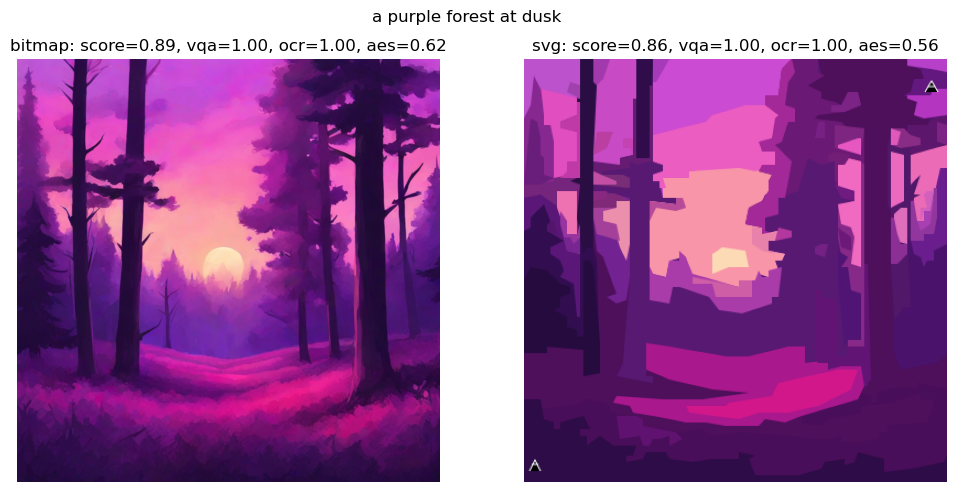

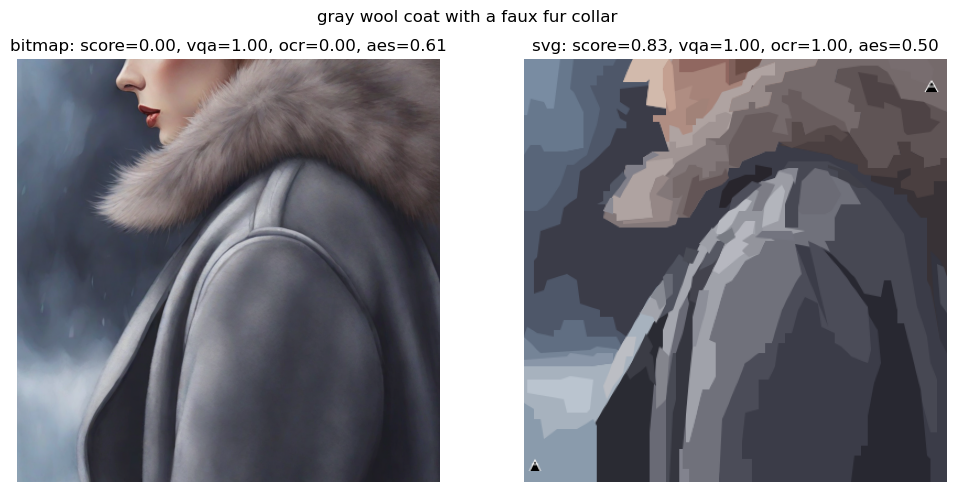

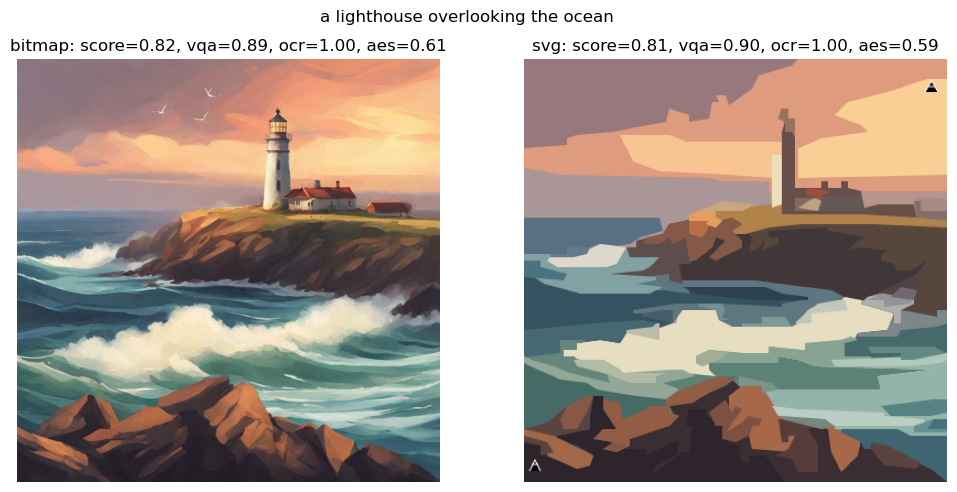

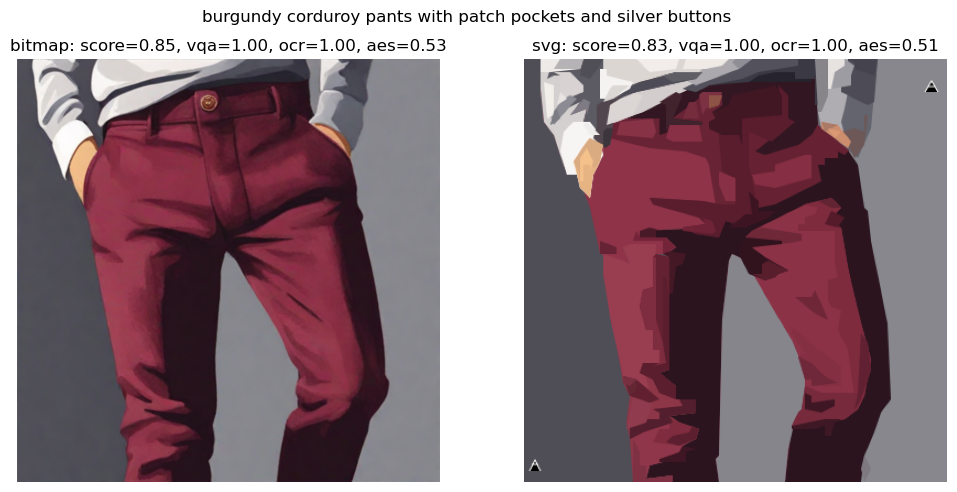

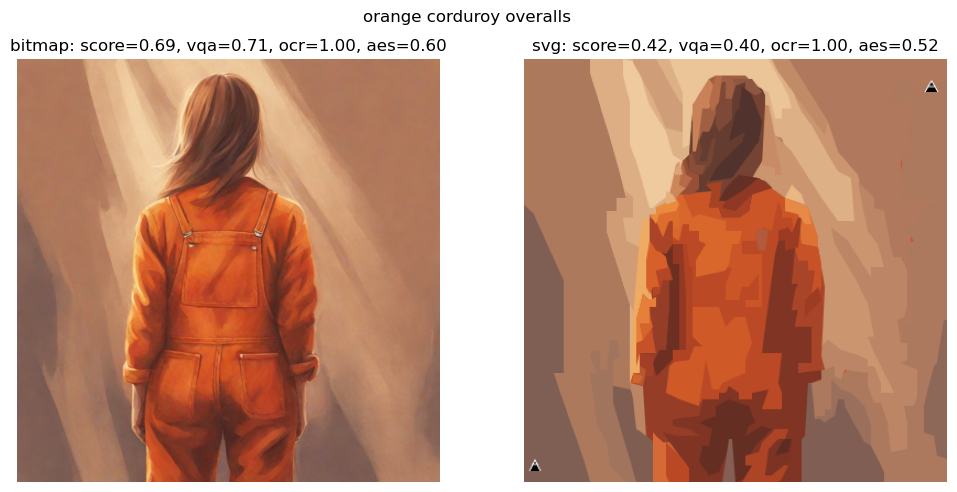

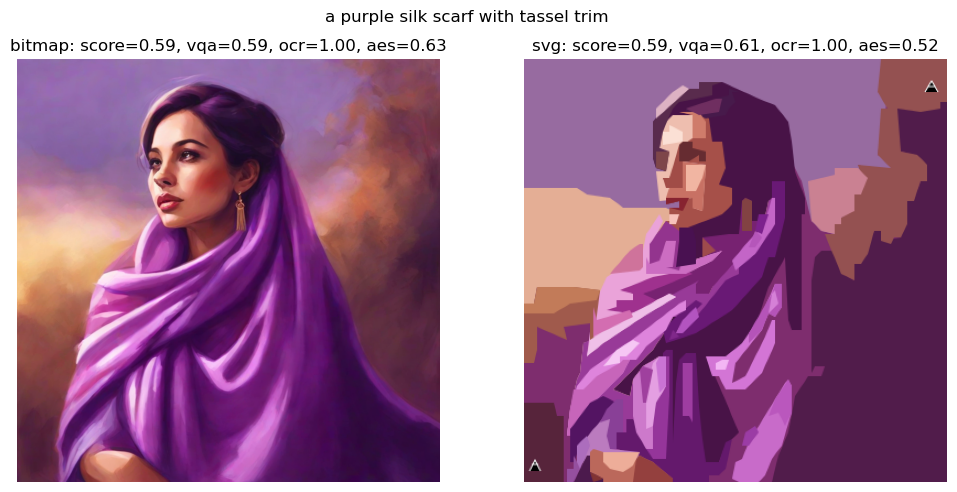

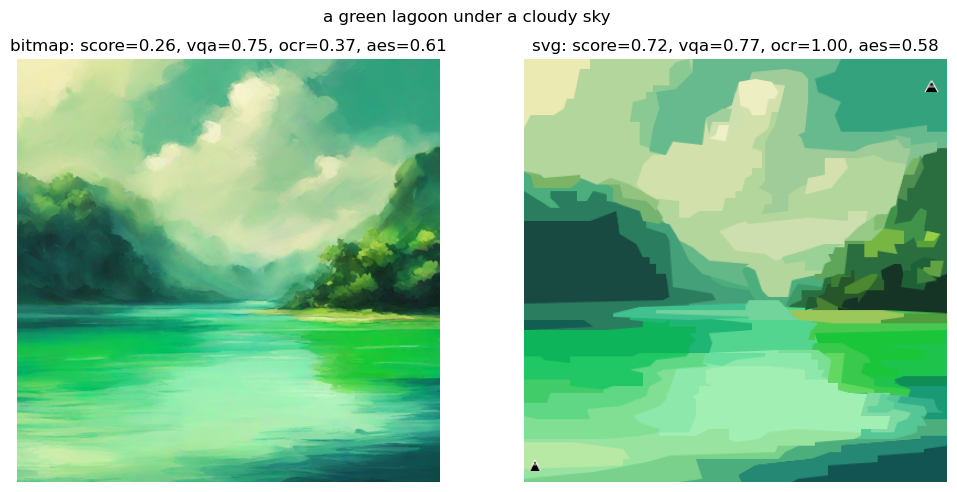

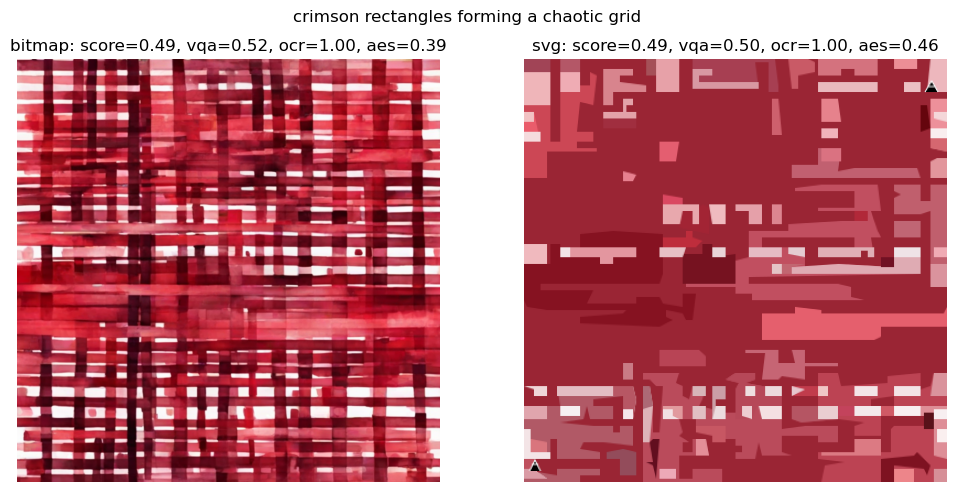

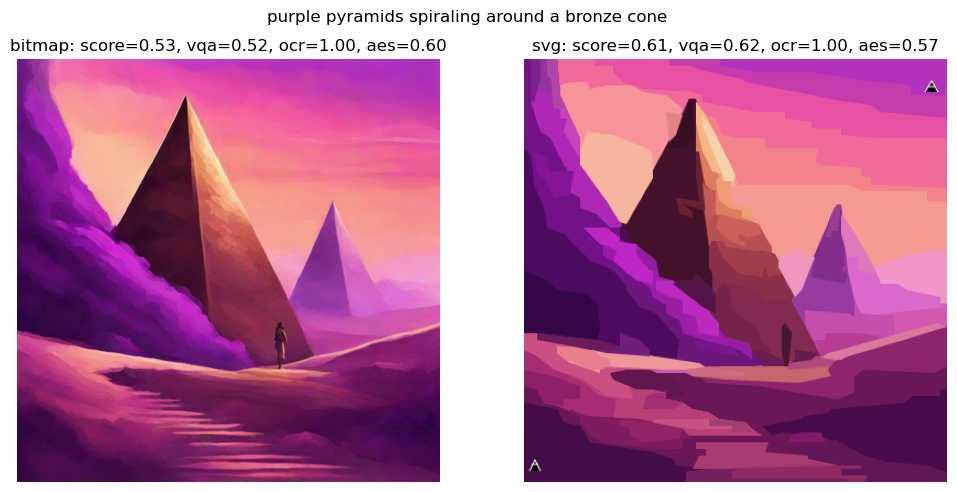

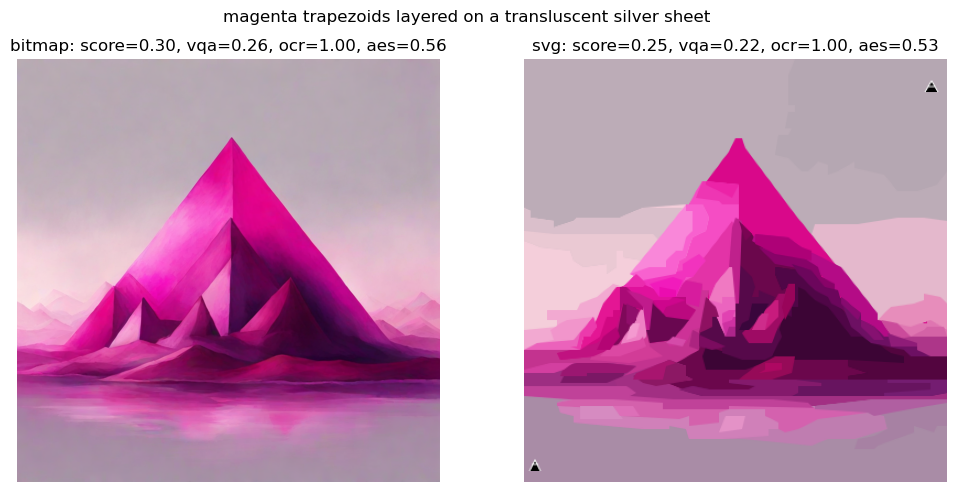

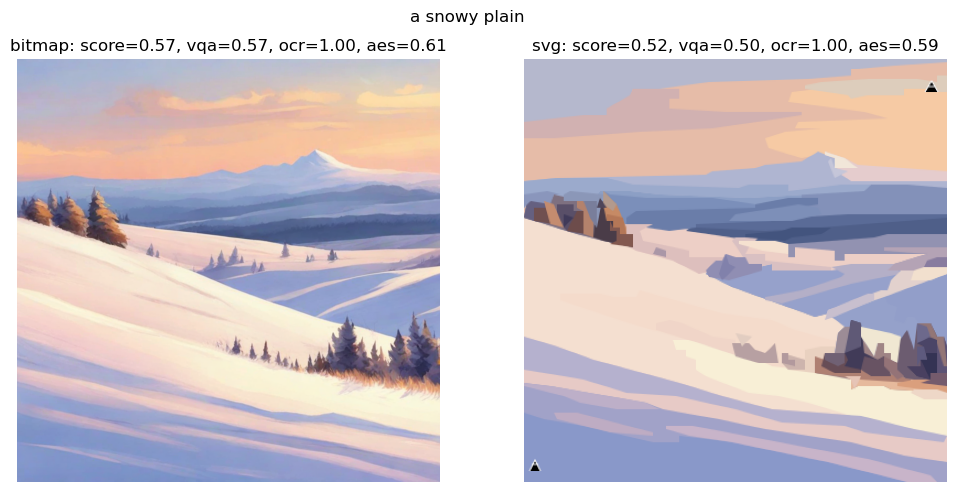

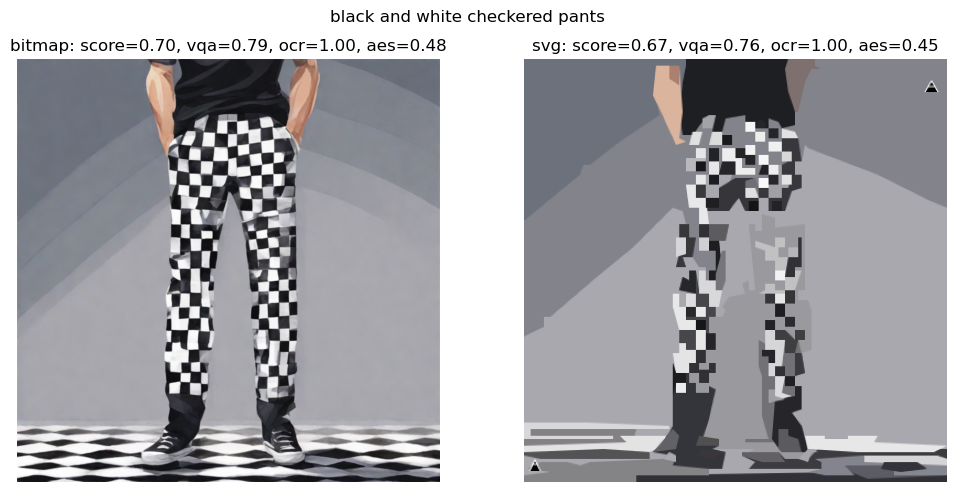

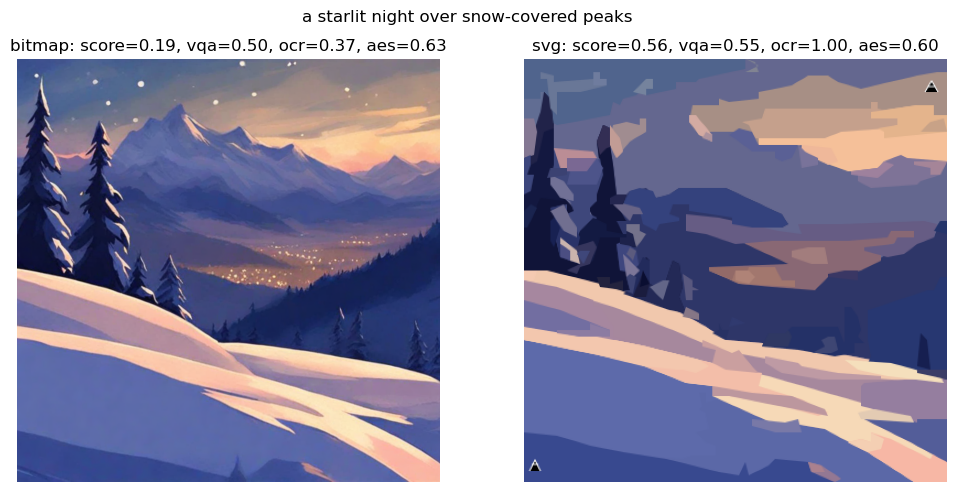

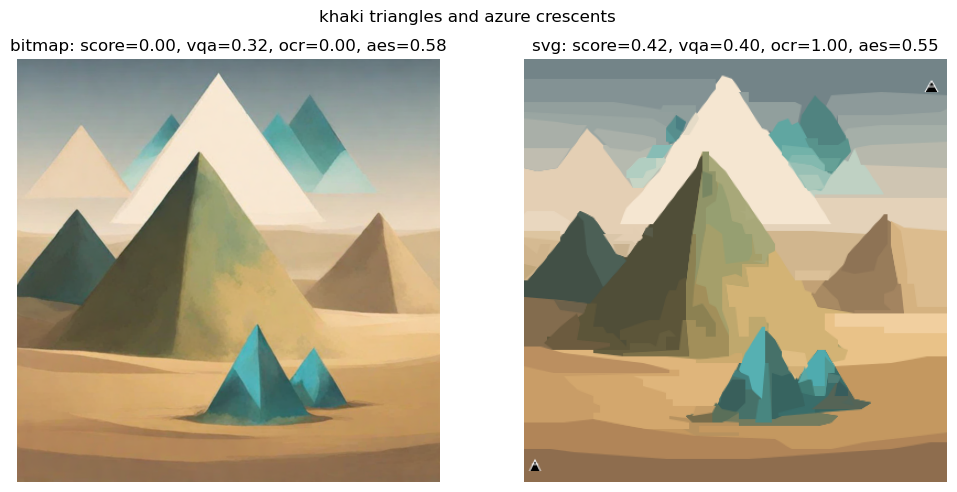

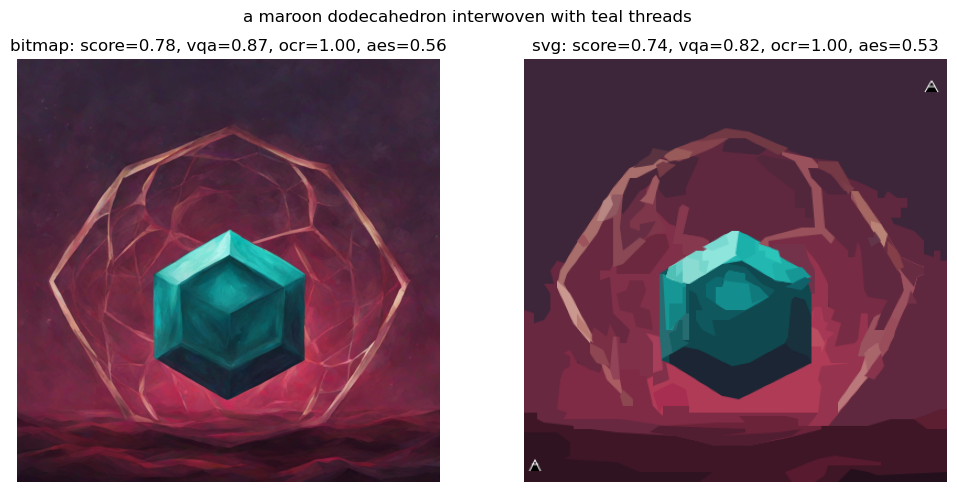

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

train_df['raw_res'] = train_df.description.progress_apply(model.predict_impl)

train_df['svg'] = train_df.raw_res.apply(lambda x: x[0])
train_df['bitmap'] = train_df.raw_res.apply(lambda x: x[1])

train_df['bitmap_score'] = train_df.progress_apply(
    lambda r: bitmap_score_instance(r.multiple_choice_qa, r.bitmap, random_seed=42),
    axis=1,
)

train_df['svg_score'] = train_df.progress_apply(
    lambda r: metric.score_instance(r.multiple_choice_qa, r.svg, random_seed=42),
    axis=1,
)

for r in train_df.itertuples():
    
    b_vqa = r.bitmap_score['vqa_score']
    b_aesthetic = r.bitmap_score['aesthetic_score']
    b_ocr = r.bitmap_score['ocr_score']
    b_score = r.bitmap_score['competition_score']

    
    s_vqa = r.svg_score['vqa_score']
    s_aesthetic = r.svg_score['aesthetic_score']
    s_ocr = r.svg_score['ocr_score']
    s_score = r.svg_score['competition_score']
    
    plt.figure(figsize=(12, 6))
    plt.suptitle(r.description, y=0.93)
    
    plt.subplot(1, 2, 1)
    plt.imshow(np.array(r.bitmap))
    plt.axis('off')
    plt.title(f'bitmap: score={b_score:.2f}, vqa={b_vqa:.2f}, ocr={b_ocr:.2f}, aes={b_aesthetic:.2f}')

    plt.subplot(1, 2, 2)
    plt.imshow(metric.svg_to_png(r.svg))
    plt.axis('off')
    plt.title(f'svg: score={s_score:.2f}, vqa={s_vqa:.2f}, ocr={s_ocr:.2f}, aes={s_aesthetic:.2f}')

## score of train set

In [22]:
mean_bitmap_score = pd.DataFrame(train_df['bitmap_score'].tolist()).mean(axis=0)
print(mean_bitmap_score)
print('='*20)
mean_svg_score = pd.DataFrame(train_df['svg_score'].tolist()).mean(axis=0)
print(mean_svg_score)

print()
print(f'Original bitmap score: {mean_bitmap_score.competition_score}')
print(f'Final svg score: {mean_svg_score.competition_score}')

competition_score    0.511071
vqa_score            0.686198
ocr_score            0.782409
aesthetic_score      0.573587
dtype: float64
competition_score    0.622914
vqa_score            0.670275
ocr_score            1.000000
aesthetic_score      0.537580
dtype: float64

Original bitmap score: 0.5110708613252117
Final svg score: 0.6229142858823725


## Extra Test generated with Gemini 2.0 Flash

In [23]:
%%capture cap
import pandas as pd
import json
val_df = pd.read_csv(f'validation.csv')

val_df = val_df.groupby('id').apply(lambda df: df.to_dict(orient='list'), include_groups=False)
val_df = val_df.reset_index(name='qa')

val_df['description'] = val_df.qa.apply(lambda qa: qa['description'][0])
val_df['question'] = val_df.qa.apply(lambda qa: str(json.dumps(qa['question'], ensure_ascii=False)))
val_df['answer'] = val_df.qa.apply(lambda qa: str(json.dumps(qa['answer'], ensure_ascii=False)))
val_df['choices'] = val_df.qa.apply(lambda qa: str(json.dumps([eval(x) for x in qa['choices']], ensure_ascii=False)))

val_df = val_df.drop("qa", axis=1)
# val_df.head()

val_df['multiple_choice_qa'] = val_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

# val_df.head(1)
import torch

val_df['raw_res'] = val_df.description.progress_apply(model.predict_impl)
val_df['svg'] = val_df.raw_res.apply(lambda x: x[0])
val_df['bitmap'] = val_df.raw_res.apply(lambda x: x[1])

val_df['bitmap_score'] = val_df.progress_apply(
    lambda r: bitmap_score_instance(r.multiple_choice_qa, r.bitmap, random_seed=42),
    axis=1,
)
val_df['svg_score'] = val_df.progress_apply(
    lambda r: metric.score_instance(r.multiple_choice_qa, r.svg, random_seed=42),
    axis=1,
)


for r in val_df.itertuples():
    
    b_vqa = r.bitmap_score['vqa_score']
    b_aesthetic = r.bitmap_score['aesthetic_score']
    b_ocr = r.bitmap_score['ocr_score']
    b_score = r.bitmap_score['competition_score']

    
    s_vqa = r.svg_score['vqa_score']
    s_aesthetic = r.svg_score['aesthetic_score']
    s_ocr = r.svg_score['ocr_score']
    s_score = r.svg_score['competition_score']
    
    plt.figure(figsize=(6, 3))
    plt.suptitle(r.description, y=0.93, fontsize=5)
    
    plt.subplot(1, 2, 1)
    plt.imshow(np.array(r.bitmap))
    plt.axis('off')
    plt.title(f'bitmap: score={b_score:.2f}, vqa={b_vqa:.2f}, ocr={b_ocr:.2f}, aes={b_aesthetic:.2f}', fontsize=5)

    plt.subplot(1, 2, 2)
    plt.imshow(metric.svg_to_png(r.svg))
    plt.axis('off')
    plt.title(f'svg: score={s_score:.2f}, vqa={s_vqa:.2f}, ocr={s_ocr:.2f}, aes={s_aesthetic:.2f}', fontsize=5)



## score of extra train set

In [24]:
mean_bitmap_score = pd.DataFrame(val_df['bitmap_score'].tolist()).mean(axis=0)
print(mean_bitmap_score)
print('='*20)
mean_svg_score = pd.DataFrame(val_df['svg_score'].tolist()).mean(axis=0)
print(mean_svg_score)

print()
print(f'Original bitmap score: {mean_bitmap_score.competition_score}')
print(f'Final svg score: {mean_svg_score.competition_score}')

competition_score    0.500906
vqa_score            0.839128
ocr_score            0.653286
aesthetic_score      0.581510
dtype: float64
competition_score    0.727865
vqa_score            0.814407
ocr_score            1.000000
aesthetic_score      0.534597
dtype: float64

Original bitmap score: 0.5009062076806253
Final svg score: 0.7278646075183564
